In [43]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s


In [158]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
a_coeffs = [0.5, 0.1, 0.01, 0.02]
b_coeffs = [2, 1, 0.1, 0.02]
#get bpmeth opbject
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
#expansion.plot_components()
# plt.xlabel('s')
# plt.xlim((0,1))

/home/fmarcoli/bpmeth/src/bpmeth/generate_expansion.py:96: UserWarning: The laplacian could not be evaluated
  warnings.warn("The laplacian could not be evaluated")


Scalar potential phi(x,y,s): 0.000833333333333333*x**4 + 0.00166666666666667*x**3 + 0.05*x**2 + 0.5*x + 0.000833333333333333*y**4 - y**3*(0.12*x + 0.6)/36 - y**2*(0.24*x**2 + 0.24*x + 2.4)/48 + y*(0.02*x**3 + 0.3*x**2 + 6*x + 12)/6
Scalar potential phi at (0.4,0.2,0.5): 0.687516


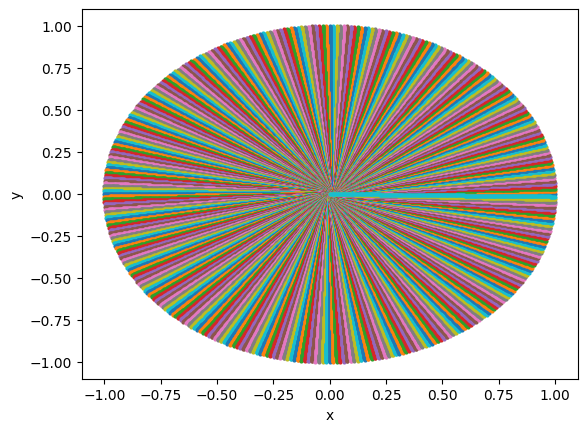

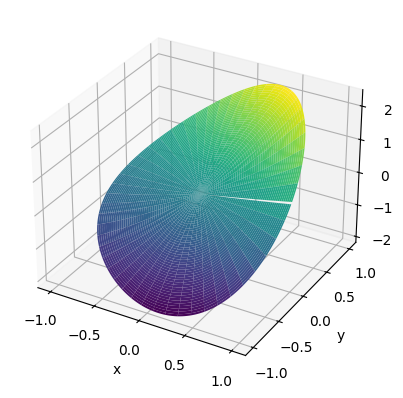

In [171]:
phi=expansion.get_phi()
print("Scalar potential phi(x,y,s):", phi)

XYS=(x,y,s)#symbolic expressions

phi_func = lambdify(XYS, phi, 'numpy')#from symbolic to numerical function
print("Scalar potential phi at (0.4,0.2,0.5):", phi_func(0.4,0.2,0.5))
#define r, theta, s axes to convert the symbolic expression of phi into a numerical array
# npoints=201
# xa= np.linspace(-1,1,npoints) 
# ya=np.linspace(-1,1,npoints)
rmin, rmax, nr = 0.001, 1.001, 250
ntheta = 400
rr = np.linspace(rmin, rmax, nr)

tt = np.arange(ntheta)/ntheta*2*np.pi
ss = np.linspace(-1,1, 40)
rarr, tarr, sarr = np.meshgrid(rr, tt, ss, indexing='ij')
xarr = rarr*np.cos(tarr)
yarr = rarr*np.sin(tarr)
#make a 3d plot of phi as a function of x and y for a fixed s
plt.plot(xarr[:,:,0], yarr[:,:,0], 'o', markersize=2)
plt.xlabel("x")
plt.ylabel("y")
P = phi_func(xarr[:,:,0], yarr[:,:,0], 0.)#s=0 is the middle  of the magnet
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xarr[:,:,0], yarr[:,:,0], P, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('phi(x,y,s=0.5)')
plt.show()

In [160]:
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func)#with lambdify=False
# Evaluate on grid
#X,Y,S = np.meshgrid(xa, ya, sa, indexing='ij')
Bx_ana = Bx_func(xarr, yarr, sarr)
By_ana = By_func(xarr, yarr, sarr)
Bs_ana = Bs_func(xarr, yarr, sarr)

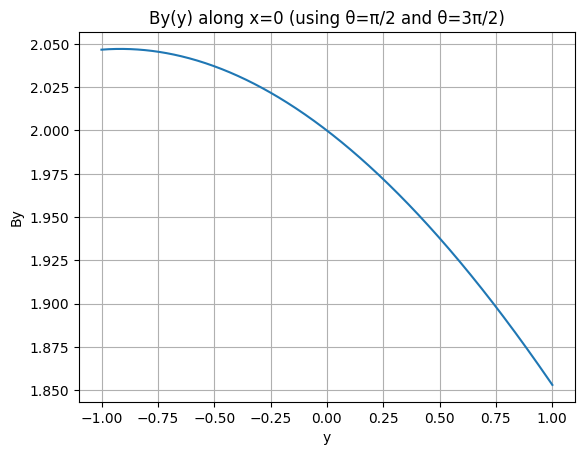

In [161]:
#Plot By as a function of y for x=0
islice = 20   # choose an s index
# θ = π/2 → positive y
itheta_pos = np.argmin(np.abs(tt - np.pi/2))
y_pos = yarr[:,itheta_pos, islice]
By_pos = By_ana[:, itheta_pos, islice]

# θ = 3π/2 → negative y
itheta_neg = np.argmin(np.abs(tt - 3*np.pi/2))
y_neg = yarr[:,itheta_neg, islice]
By_neg = By_ana[:, itheta_neg, islice]

# Combine and sort
y_all = np.concatenate([y_neg, y_pos])
By_all = np.concatenate([By_neg, By_pos])

order = np.argsort(y_all)
y_all = y_all[order]
By_all = By_all[order]

plt.plot(y_all, By_all)
plt.xlabel("y")
plt.ylabel("By")
plt.title("By(y) along x=0 (using θ=π/2 and θ=3π/2)")
plt.grid(True)


In [162]:
Ax, Ay, As = expansion.get_A(lambdify=True)
#print("Ax:", Ax, "Ay:", Ay, "As:", As)#with lambdify False
Ax_ana = Ax(xarr, yarr, sarr)
Ay_ana = Ay(xarr, yarr, sarr)
As_ana = As(xarr, yarr, sarr)


In [163]:
#then take the curl of A from finite differences and compare with the original B field
def curl_cylindrical_from_cartesian(Ax, Ay, Az, rarr, tarr, sarr):
    """
    Compute curl(A) on a cylindrical grid (r, theta, s),
    where A is given in Cartesian components (Ax, Ay, Az).
    """

    # ---------------------------------------------------------
    # 1. Extract axes and spacings
    # ---------------------------------------------------------
    r_axis     = rarr[:,0,0]
    theta_axis = tarr[0,:,0]
    s_axis     = sarr[0,0,:]

    dr     = r_axis[1]     - r_axis[0]
    dtheta = theta_axis[1] - theta_axis[0]
    ds     = s_axis[1]     - s_axis[0]

    # ---------------------------------------------------------
    # 2. Convert A from Cartesian → cylindrical components
    # ---------------------------------------------------------
    cos_t = np.cos(tarr)
    sin_t = np.sin(tarr)

    Ar     =  Ax*cos_t + Ay*sin_t
    Atheta = -Ax*sin_t + Ay*cos_t
    Az_cyl =  Az

    # ---------------------------------------------------------
    # 3. Compute partial derivatives
    # ---------------------------------------------------------
    dAr_dtheta     = np.gradient(Ar,     dtheta, axis=1)
    dAtheta_dtheta = np.gradient(Atheta, dtheta, axis=1)
    dAz_dtheta     = np.gradient(Az_cyl, dtheta, axis=1)

    dAr_dr     = np.gradient(Ar,     dr, axis=0)
    dAtheta_dr = np.gradient(Atheta, dr, axis=0)
    dAz_dr     = np.gradient(Az_cyl, dr, axis=0)

    dAr_dz     = np.gradient(Ar,     ds, axis=2)
    dAtheta_dz = np.gradient(Atheta, ds, axis=2)
    dAz_ds     = np.gradient(Az_cyl, ds, axis=2)

    # ---------------------------------------------------------
    # 4. Curl in cylindrical coordinates
    # ---------------------------------------------------------
    r = rarr

    curl_r = (1/r) * dAz_dtheta - dAtheta_dz
    curl_theta = dAr_dz - dAz_dr

    rAtheta = r * Atheta
    d_rAtheta_dr = np.gradient(rAtheta, dr, axis=0)

    curl_z = (1/r) * d_rAtheta_dr - (1/r) * dAr_dtheta

    # ---------------------------------------------------------
    # 5. Convert curl back to Cartesian components
    # ---------------------------------------------------------
    curl_x = curl_r*cos_t - curl_theta*sin_t
    curl_y = curl_r*sin_t + curl_theta*cos_t
    curl_s = curl_z

    return curl_x, curl_y, curl_s

curl_x, curl_y, curl_s = curl_cylindrical_from_cartesian(Ax_ana, Ay_ana, As_ana, rarr, tarr, sarr)
#print(curl_Ax.shape, Bx_ana.shape)
# Compare with computed curl
print("Max difference in Bx:", np.max(np.abs(curl_x - Bx_ana)))
print("Max relative difference in By:", np.max(np.abs(curl_y - By_ana))/np.max(np.abs(By_ana)))
print("Max difference in Bs:", np.max(np.abs(curl_s - Bs_ana)))


Max difference in Bx: 0.03289191675697101
Max relative difference in By: 0.0007390796496990064
Max difference in Bs: 0.0


(250, 400, 40)
30


/tmp/fmarcoli/ipykernel_54939/1338873760.py:10: RuntimeWarning: invalid value encountered in divide
  plt.plot(truncatedxarr, (curl_s[position]-Bs_ana[position])/(Bs_ana[position]), label='Curl(A)_s -Bs')


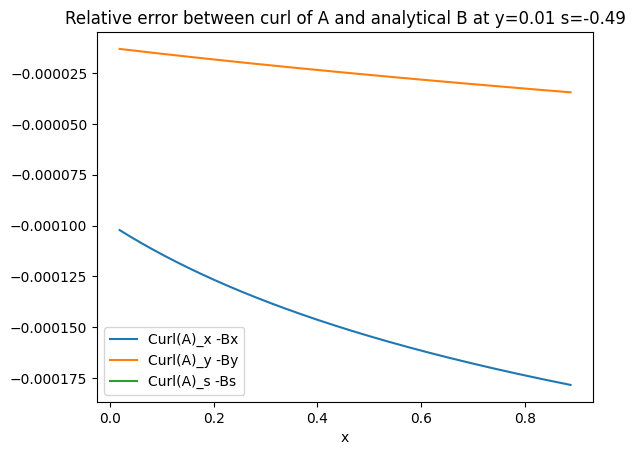

In [174]:
npoints=len(xarr)
print(xarr.shape)
truncatedxarr=xarr[5:npoints-1,30,10]#to avoid boundary effects from finite differences
#truncateds=sa[5:npoints-5]#to avoid boundary effects from finite differences
#position=(45, 54,slice(5,npoints-5))#x=0, y=0, all s
position=(slice(5,npoints-1), 30, 10)#all x, y=fixed, s=fixed
print(position[1])
plt.plot(truncatedxarr, (curl_x[position]-Bx_ana[position])/(Bx_ana[position]), label='Curl(A)_x -Bx')
plt.plot(truncatedxarr, (curl_y[position]-By_ana[position])/(By_ana[position]), label='Curl(A)_y -By')
plt.plot(truncatedxarr, (curl_s[position]-Bs_ana[position])/(Bs_ana[position]), label='Curl(A)_s -Bs')
#plt.ylim((np.min((curl_Ay[position]-By_ana[position])/By_ana[position]), np.max((curl_Ay[position]-By_ana[position])/By_ana[position])))
plt.legend()
plt.title('Relative error between curl of A and analytical B at y='+str(np.round(yarr[position][1],2)) +" s="+str(np.round(sarr[position][2],2)))
plt.xlabel('x')
plt.show()


Text(0.5, 0, 'x')

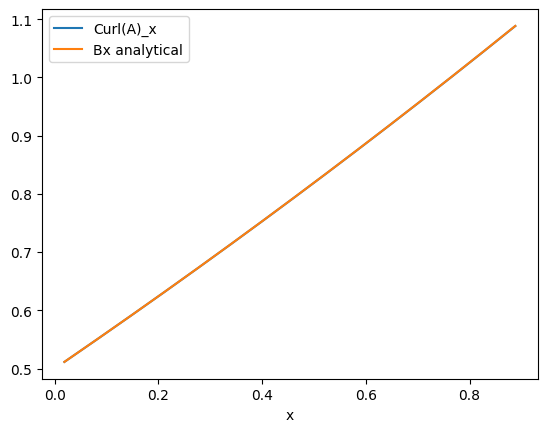

In [165]:
plt.plot(truncatedxarr, curl_x[position], label='Curl(A)_x')
plt.plot(truncatedxarr,Bx_ana[position], label='Bx analytical')
plt.legend()
plt.xlabel('x')

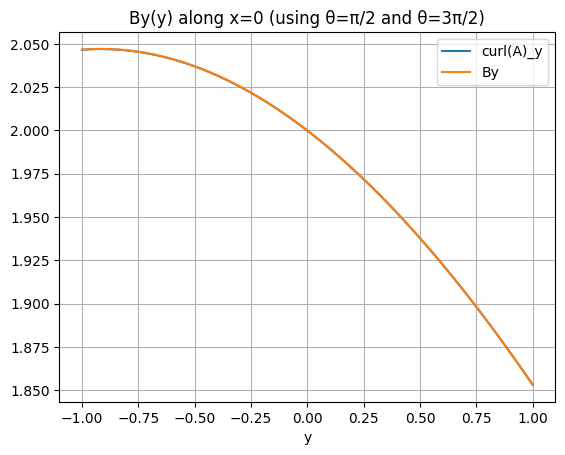

In [166]:

islice = 20   # choose an s index

# θ = π/2 → positive y
itheta_pos = np.argmin(np.abs(tt - np.pi/2))
y_pos = yarr[:,itheta_pos, islice]
curly_pos = curl_y[:, itheta_pos, islice]

# θ = 3π/2 → negative y
itheta_neg = np.argmin(np.abs(tt - 3*np.pi/2))
y_neg = yarr[:,itheta_neg, islice]
curly_neg = curl_y[:, itheta_neg, islice]

# Combine and sort
y_all = np.concatenate([y_neg, y_pos])
curly_all = np.concatenate([curly_neg, curly_pos])
order = np.argsort(y_all)
y_all = y_all[order]
curly_all = curly_all[order]

plt.plot(y_all, curly_all, label='curl(A)_y')
plt.plot(y_all, By_all, label='By')
plt.xlabel("y")
plt.title("By(y) along x=0 (using θ=π/2 and θ=3π/2)")

plt.legend()
plt.grid(True)


In [167]:
print("rmin=", rmin, "rmax=", rmax, "step=",(rmax-rmin)/nr)
print(rr[5:55])

rmin= 0.001 rmax= 1.001 step= 0.003999999999999999
[0.02108032 0.02509639 0.02911245 0.03312851 0.03714458 0.04116064
 0.04517671 0.04919277 0.05320884 0.0572249  0.06124096 0.06525703
 0.06927309 0.07328916 0.07730522 0.08132129 0.08533735 0.08935341
 0.09336948 0.09738554 0.10140161 0.10541767 0.10943373 0.1134498
 0.11746586 0.12148193 0.12549799 0.12951406 0.13353012 0.13754618
 0.14156225 0.14557831 0.14959438 0.15361044 0.15762651 0.16164257
 0.16565863 0.1696747  0.17369076 0.17770683 0.18172289 0.18573896
 0.18975502 0.19377108 0.19778715 0.20180321 0.20581928 0.20983534
 0.21385141 0.21786747]


In [168]:
# Choose a fixed s value (s=0 is the magnet center)
s_fixed = 0.0
datafieldmap = np.column_stack([
    xarr.ravel(),
    yarr.ravel(),
    sarr.ravel(),
    curl_x.ravel(),
    curl_y.ravel(),
    curl_s.ravel()
])
curlfieldmap =bpmeth.fieldmaps.Fieldmap(datafieldmap)
bnianfromcurl=curlfieldmap.harmonic_analysis_at_s(spos=s_fixed,order=4, rmin=0.02108032, rmax=0.21786747, nr=50, radius=0.006 )
bn=bnianfromcurl.real[:len(b_coeffs)]
an=bnianfromcurl.imag[:len(a_coeffs)]

print("recovered bn(0): ",bn )
print("Original bn(0): ", b_coeffs)
print("recovered an(0): ", an )
print("Original an(0): ", a_coeffs)

recovered bn(0):  [0. 0. 0. 0.]
Original bn(0):  [2, 1, 0.1, 0.02]
recovered an(0):  [0. 0. 0. 0.]
Original an(0):  [0.5, 0.1, 0.01, 0.02]


In [169]:
#Since there is no s dependence in the original coefficients i can use fft
bnianfft=curlfieldmap.fft_at_s(spos=s_fixed, r=0.22, radius=0.06)
bnfft=bnianfft.real[:len(b_coeffs)]
print("bn recovered by Fourier transform: ",bnfft )
print("Original bn: ", b_coeffs)

bn recovered by Fourier transform:  [1.99995963 0.99187062 0.09848173 0.02115321]
Original bn:  [2, 1, 0.1, 0.02]


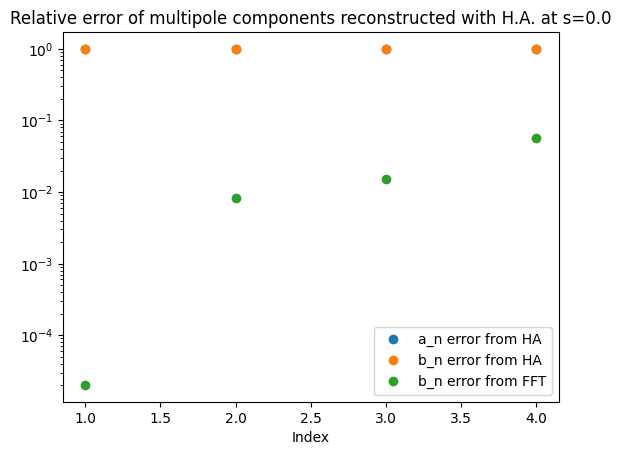

In [170]:
p=4#how many values to plot

plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_coeffs[:p]-an[:p])/a_coeffs[:p], 'o', label='a_n error from HA')
plt.yscale('log')
plt.xlabel('Index')

plt.title('Relative error of multipole components reconstructed with H.A. at s=' + str(s_fixed))
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_coeffs[:p]-bn[:p])/max(b_coeffs[:p],b_coeffs[:p]), 'o', label='b_n error from HA')
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_coeffs[:p]-bnfft[:p])/b_coeffs[:p], 'o', label='b_n error from FFT')
plt.legend()
plt.show()